# Power Grid Stability Risk Prediction - Model Training

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split,KFold,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

In [12]:
df=pd.read_csv("Data_for_UCI_named.csv")
df.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


### 1. tau1, tau2, tau3, tau4  
👉 **Time constants of grid nodes**  

Represent the dynamic response speed of each node  
Higher values → slower system response  
Lower values → faster system response  


### 2. p1, p2, p3, p4    (power)
👉 **Power injection / consumption at each node**  

Positive → power generation  
Negative → power consumption (load)  
Reflects the balance between supply and demand  


### 3. g1, g2, g3, g4    (gain)
👉 **Control gain / system parameters**  

Determine how strongly each node responds to disturbances  (strength of reaction)
Higher values → stronger corrective action  
Lower values → weaker system control  


### 4. stab  
👉 **Stability score (continuous output)**  

Derived from system dynamics (e.g., eigenvalue-based stability)  
Negative → stable system  
Positive → unstable system  


### 5. stabf  
👉 **Binary stability label**  

stable  
unstable  

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [14]:
df.isnull().sum()

tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

In [15]:
df.dtypes

tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stab     float64
stabf     object
dtype: object

In [16]:
df.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [17]:
df.columns

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='object')

In [18]:
df=df.drop("stabf",axis=1)
df.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860


## EDA

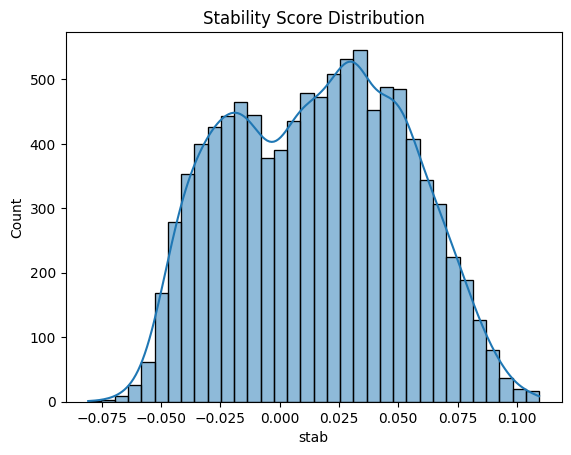

In [19]:
sns.histplot(df["stab"],kde=True)
plt.title("Stability Score Distribution")
plt.show()

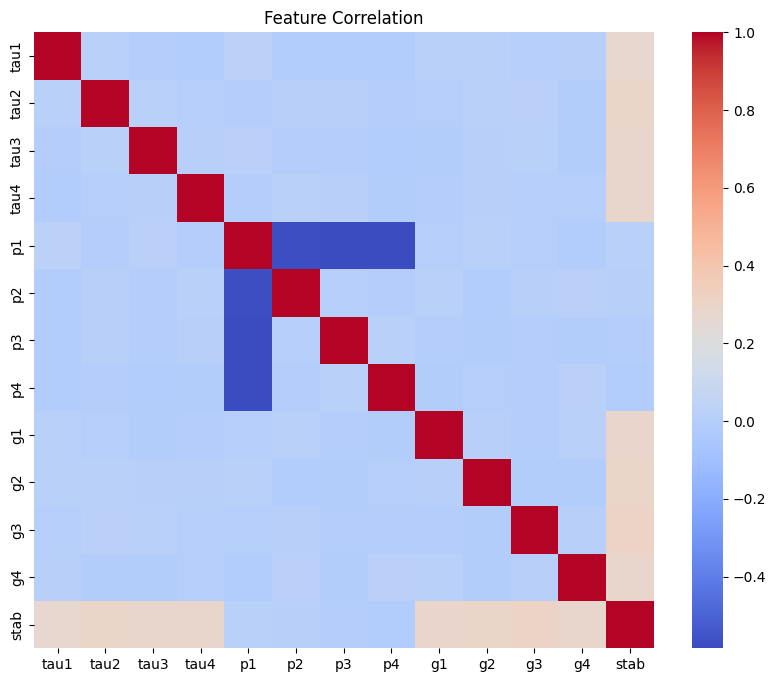

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=False,cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [21]:
df.columns

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab'],
      dtype='object')

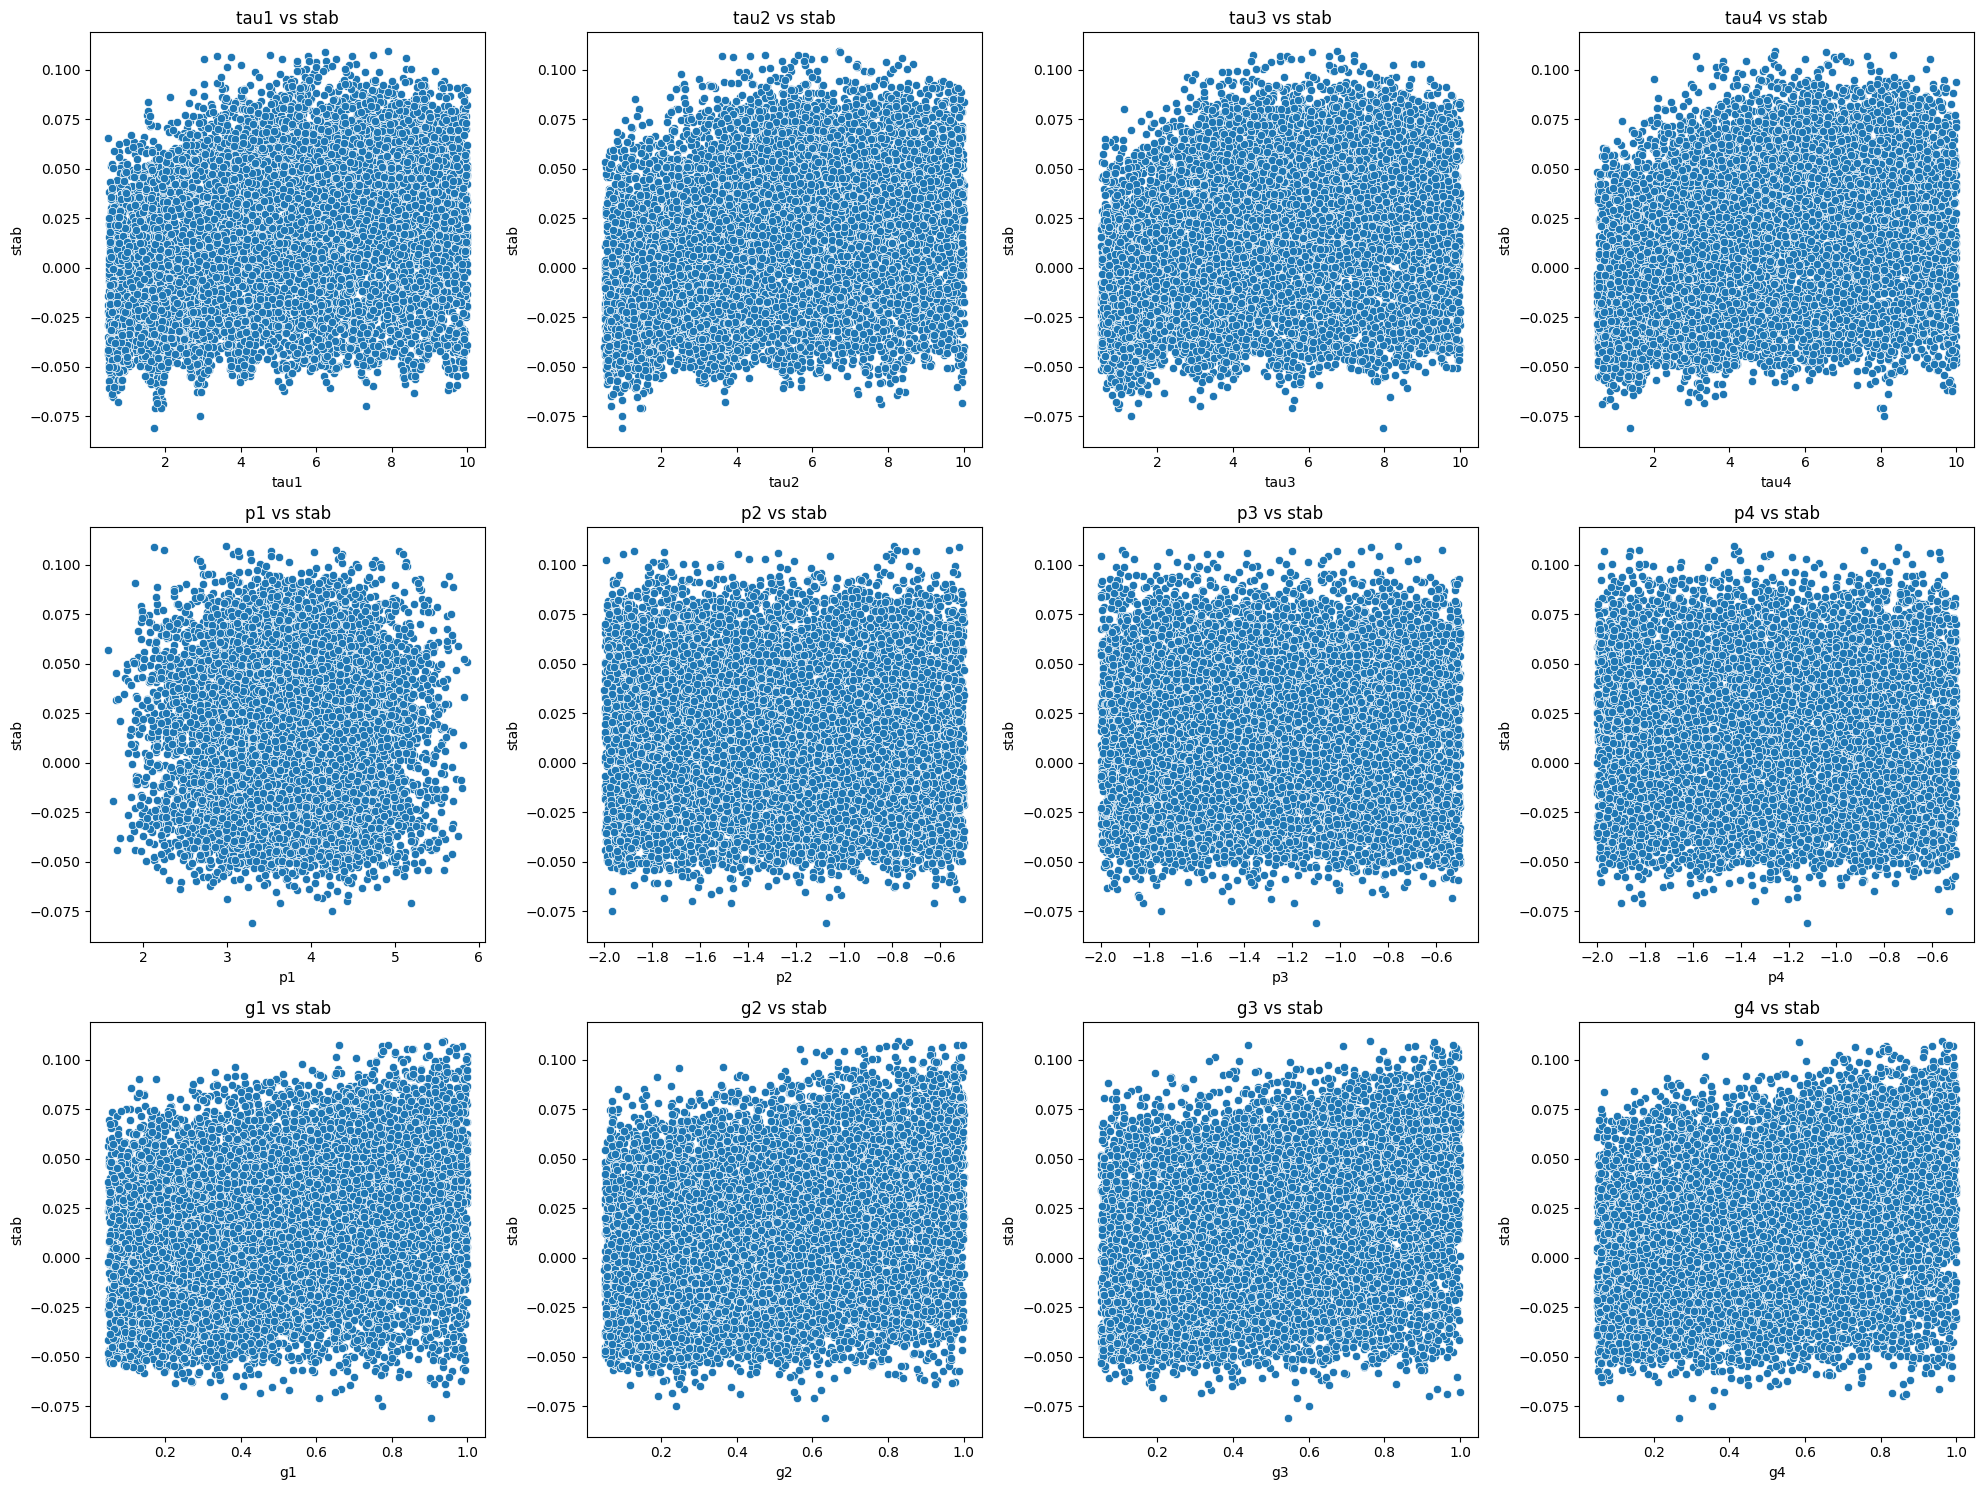

In [22]:
plt.figure(figsize=(20,15))
plt.subplot(3,4,1)
sns.scatterplot(x=df["tau1"],y=df["stab"])
plt.title("tau1 vs stab")

plt.subplot(3,4,2)
sns.scatterplot(x=df["tau2"],y=df["stab"])
plt.title("tau2 vs stab")

plt.subplot(3,4,3)
sns.scatterplot(x=df["tau3"],y=df["stab"])
plt.title("tau3 vs stab")

plt.subplot(3,4,4)
sns.scatterplot(x=df["tau4"],y=df["stab"])
plt.title("tau4 vs stab")

plt.subplot(3,4,5)
sns.scatterplot(x=df["p1"],y=df["stab"])
plt.title("p1 vs stab")

plt.subplot(3,4,6)
sns.scatterplot(x=df["p2"],y=df["stab"])
plt.title("p2 vs stab")

plt.subplot(3,4,7)
sns.scatterplot(x=df["p3"],y=df["stab"])
plt.title("p3 vs stab")

plt.subplot(3,4,8)
sns.scatterplot(x=df["p4"],y=df["stab"])
plt.title("p4 vs stab")

plt.subplot(3,4,9)
sns.scatterplot(x=df["g1"],y=df["stab"])
plt.title("g1 vs stab")

plt.subplot(3,4,10)
sns.scatterplot(x=df["g2"],y=df["stab"])
plt.title("g2 vs stab")

plt.subplot(3,4,11)
sns.scatterplot(x=df["g3"],y=df["stab"])
plt.title("g3 vs stab")

plt.subplot(3,4,12)
sns.scatterplot(x=df["g4"],y=df["stab"])
plt.title("g4 vs stab")

plt.tight_layout()
plt.show()

In [23]:
x=df.drop("stab",axis=1)
y=df["stab"]

In [24]:
x

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2.930406,9.487627,2.376523,6.187797,3.343416,-0.658054,-1.449106,-1.236256,0.601709,0.779642,0.813512,0.608385
9996,3.392299,1.274827,2.954947,6.894759,4.349512,-1.663661,-0.952437,-1.733414,0.502079,0.567242,0.285880,0.366120
9997,2.364034,2.842030,8.776391,1.008906,4.299976,-1.380719,-0.943884,-1.975373,0.487838,0.986505,0.149286,0.145984
9998,9.631511,3.994398,2.757071,7.821347,2.514755,-0.966330,-0.649915,-0.898510,0.365246,0.587558,0.889118,0.818391


In [25]:
y

0       0.055347
1      -0.005957
2       0.003471
3       0.028871
4       0.049860
          ...   
9995    0.023892
9996   -0.025803
9997   -0.031810
9998    0.037789
9999    0.045263
Name: stab, Length: 10000, dtype: float64

In [26]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [27]:
print("xtrain shape:",xtrain.shape)
print("xtest shape:",xtest.shape)
print("ytrain shape:",ytrain.shape)
print("ytest shape:",ytest.shape)

xtrain shape: (8000, 12)
xtest shape: (2000, 12)
ytrain shape: (8000,)
ytest shape: (2000,)


In [28]:
xtrain

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
9254,6.587242,8.255999,8.109960,4.457904,4.332937,-1.073779,-1.371388,-1.887770,0.166933,0.612514,0.792247,0.836127
1561,0.676193,0.781086,5.556240,3.765235,2.931210,-1.062958,-1.175796,-0.692456,0.740131,0.772031,0.420697,0.839775
1670,4.757109,8.891698,1.778212,9.795918,5.238057,-1.961965,-1.705948,-1.570144,0.850271,0.601201,0.302983,0.126409
6087,3.343688,8.461652,8.675216,2.197498,3.360289,-1.189211,-1.064192,-1.106886,0.961836,0.686392,0.444109,0.696517
6669,7.581260,4.061263,6.192641,6.557269,3.221193,-1.433562,-0.591071,-1.196560,0.217076,0.680618,0.457295,0.726299
...,...,...,...,...,...,...,...,...,...,...,...,...
5734,3.216954,1.561568,7.399332,1.219421,4.001156,-0.757407,-1.863784,-1.379964,0.263501,0.911023,0.865559,0.906780
5191,7.730023,8.899012,6.714530,0.889282,3.538269,-1.356540,-1.379289,-0.802440,0.190749,0.663272,0.183154,0.709821
5390,6.059670,6.724599,1.519847,3.760452,2.613370,-0.743728,-0.533816,-1.335826,0.640419,0.474879,0.546616,0.346686
860,0.521154,4.363636,1.134858,0.831704,3.248480,-0.731272,-1.833907,-0.683301,0.386320,0.336058,0.883860,0.871166


In [ ]:
def get_score(model,xtrain,xtest,ytrain,ytest,scale=False):
    if scale:
        t_scaler=StandardScaler()
        xtrain=t_scaler.fit_transform(xtrain)
        xtest=t_scaler.transform(xtest)

    model.fit(xtrain,ytrain)
    ypred=model.predict(xtest)
    return r2_score(ytest,ypred)



fold=KFold(n_splits=5,shuffle=True,random_state=42)


In [ ]:
lnr_score=[]
rdg_score=[]
lso_score=[]
dt_score=[]
rf_score=[]
gb_score=[]
svr_score=[]
knn_score=[]
xgb_score=[]


for train,test in fold.split(x,y):
    x_train,x_test,y_train,y_test=x.iloc[train],x.iloc[test],y.iloc[train],y.iloc[test]
    lnr_score.append(get_score(LinearRegression(),x_train,x_test,y_train,y_test,scale=True))
    dt_score.append(get_score(DecisionTreeRegressor(random_state=42),x_train,x_test,y_train,y_test))
    rf_score.append(get_score(RandomForestRegressor(random_state=42),x_train,x_test,y_train,y_test))
    gb_score.append(get_score(GradientBoostingRegressor(random_state=42),x_train,x_test,y_train,y_test))
    svr_score.append(get_score(SVR(),x_train,x_test,y_train,y_test,scale=True))
    knn_score.append(get_score(KNeighborsRegressor(),x_train,x_test,y_train,y_test,scale=True))
    xgb_score.append(get_score(XGBRegressor(random_state=42),x_train,x_test,y_train,y_test))



print("Scores")
print("LinearRegression",lnr_score)
print("DecisionTreeRegressor",dt_score)
print("RandomForestRegressor",rf_score)
print("GradientBoostingRegressor",gb_score)
print("SVR",svr_score)
print("KNeighborsRegressor",knn_score)
print("XGBRegressor",xgb_score)

print()
print()

print("Mean Scores")
print("LinearRegression",np.mean(lnr_score))
print("DecisionTree",np.mean(dt_score))
print("RandomForest",np.mean(rf_score))
print("GradientBoost",np.mean(gb_score))
print("SVR",np.mean(svr_score))
print("KNN",np.mean(knn_score))
print("XGBoost",np.mean(xgb_score))

In [ ]:
params={"n_estimators":[100,200],"max_depth":[3,5,7],"learning_rate":[0.01,0.1,0.2],"subsample":[0.8,1.0],"colsample_bytree":[0.8,1.0]}

In [ ]:
grid=GridSearchCV(XGBRegressor(random_state=42),params,cv=3,scoring="r2",n_jobs=-1)
grid.fit(xtrain,ytrain)

In [ ]:
grid.best_params_

In [ ]:
grid.best_score_

In [ ]:
fmodel=XGBRegressor(random_state=42,learning_rate=0.1,max_depth=7,n_estimators=200,subsample=0.8,colsample_bytree=1.0)
fmodel.fit(xtrain,ytrain)

In [36]:
fmodel=pickle.load(open("model.pkl","rb"))

In [37]:
ypred=fmodel.predict(xtest)

In [38]:
print("R2 Score:",r2_score(ytest,ypred))
print("MAE (Average absolute error):",mean_absolute_error(ytest,ypred))
print("RMSE (Root mean squared error):",np.sqrt(mean_squared_error(ytest,ypred)))

R2 Score: 0.9487832960776175
MAE (Average absolute error): 0.0061396743009480255
RMSE (Root mean squared error): 0.00833479027705165


In [39]:
# pickle.dump(fmodel,open("model.pkl","wb"))

## For Streamlit

In [40]:
fmodel=pickle.load(open("model.pkl","rb"))

In [ ]:
#Save Feature Importance


feature_importance=pd.DataFrame({
    "Feature":x.columns,
    "Importance":fmodel.feature_importances_
})

feature_importance=feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.to_csv("feature_importance.csv",index=False)

feature_importance

,Feature,Importance
10,g3,0.145782
8,g1,0.129325
11,g4,0.129018
9,g2,0.126963
3,tau4,0.121617
2,tau3,0.119637
1,tau2,0.112455
0,tau1,0.096741
4,p1,0.004789
7,p4,0.004787


In [52]:
# Save Correlation Matrix

correlation=x.corr()

correlation.to_csv("correlation_matrix.csv",index=False)
correlation

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
tau1,1.000000,0.015586,-0.005970,-0.017265,0.027183,-0.015485,-0.015924,-0.015807,0.010521,0.015350,-0.001279,0.005494
tau2,0.015586,1.000000,0.014273,-0.001965,-0.004769,0.006573,0.007673,-0.005963,-0.001742,0.015383,0.016508,-0.011764
tau3,-0.005970,0.014273,1.000000,0.004354,0.016953,-0.003134,-0.008780,-0.017531,-0.011605,0.007671,0.014702,-0.011497
tau4,-0.017265,-0.001965,0.004354,1.000000,-0.003173,0.010553,0.006169,-0.011211,-0.004149,0.008431,0.003260,-0.000491
p1,0.027183,-0.004769,0.016953,-0.003173,1.000000,-0.573157,-0.584554,-0.579239,0.000721,0.015405,0.001069,-0.015451
p2,-0.015485,0.006573,-0.003134,0.010553,-0.573157,1.000000,0.002388,-0.006844,0.015603,-0.018032,0.007555,0.019817
p3,-0.015924,0.007673,-0.008780,0.006169,-0.584554,0.002388,1.000000,0.012953,-0.003219,-0.011575,-0.005897,-0.010485
p4,-0.015807,-0.005963,-0.017531,-0.011211,-0.579239,-0.006844,0.012953,1.000000,-0.013636,0.002850,-0.003515,0.017505
g1,0.010521,-0.001742,-0.011605,-0.004149,0.000721,0.015603,-0.003219,-0.013636,1.000000,0.007559,-0.005836,0.012431
g2,0.015350,0.015383,0.007671,0.008431,0.015405,-0.018032,-0.011575,0.002850,0.007559,1.000000,-0.012809,-0.014909


In [ ]:
#Save Prediction Results

prediction_results=pd.DataFrame({
    "Actual":ytest,
    "Predicted":ypred,
    "Residual":ytest-ypred
})

prediction_results.to_csv(
    "prediction_results.csv",
    index=False
)

prediction_results.head()

,Actual,Predicted,Residual
6252,0.035629,0.032546,0.003083
4684,0.002383,0.005858,-0.003475
1731,0.030620,0.015669,0.014951
4742,-0.021962,-0.021239,-0.000723
4521,-0.039032,-0.030596,-0.008436


In [54]:
# Save Model Metrics


metrics={
    "model_type":"XGBoost Regressor",
    "r2":float(r2_score(ytest,ypred)),
    "mae":float(mean_absolute_error(ytest,ypred)),
    "rmse":float(np.sqrt(mean_squared_error(ytest,ypred)))
}
with open("model_metrics.json","w") as file:
    json.dump(metrics,file,indent=4)

metrics

{'model_type': 'XGBoost Regressor',
 'r2': 0.9487832960776175,
 'mae': 0.0061396743009480255,
 'rmse': 0.00833479027705165}

In [ ]:
# Save Dataset Summary

summary=x.describe()

summary.to_csv("dataset_summary.csv")

summary

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930


In [ ]:
# Save Feature Ranges

ranges=pd.DataFrame({
    "Feature":x.columns,
    "Minimum":x.min().values,
    "Maximum":x.max().values,
    "Mean":x.mean().values,
    "Median":x.median().values,
    "Std":x.std().values
})

ranges.to_csv(
    "feature_ranges.csv",
    index=False
)

ranges

,Feature,Minimum,Maximum,Mean,Median,Std
0,tau1,0.500793,9.999469,5.250000,5.250004,2.742548
1,tau2,0.500141,9.999837,5.250001,5.249981,2.742549
2,tau3,0.500788,9.999450,5.250004,5.249979,2.742549
3,tau4,0.500473,9.999443,5.249997,5.249734,2.742556
4,p1,1.582590,5.864418,3.750000,3.751025,0.752160
5,p2,-1.999891,-0.500108,-1.250000,-1.249966,0.433035
6,p3,-1.999945,-0.500072,-1.250000,-1.249974,0.433035
7,p4,-1.999926,-0.500025,-1.250000,-1.250007,0.433035
8,g1,0.050009,0.999937,0.525000,0.525009,0.274256
9,g2,0.050053,0.999944,0.525000,0.525003,0.274255


In [48]:
feature_thresholds=pd.DataFrame({
    "Feature":x.columns,
    "Q1":x.quantile(0.25).values,
    "Q2":x.quantile(0.50).values,
    "Q3":x.quantile(0.75).values
})

feature_thresholds.to_csv(
    "feature_thresholds.csv",
    index=False
)

feature_thresholds

,Feature,Q1,Q2,Q3
0,tau1,2.874892,5.250004,7.624690
1,tau2,2.875140,5.249981,7.624893
2,tau3,2.875522,5.249979,7.624948
3,tau4,2.874950,5.249734,7.624838
4,p1,3.218300,3.751025,4.282420
5,p2,-1.624901,-1.249966,-0.874977
6,p3,-1.625025,-1.249974,-0.875043
7,p4,-1.624960,-1.250007,-0.875065
8,g1,0.287521,0.525009,0.762435
9,g2,0.287552,0.525003,0.762490
